# 🎵 Spotify Hit Predictor

## Notebook 4 — Evaluación final en test

**Rol responsable:**  Data Scientist  
**Apoyo técnico:**  ML Engineer & Ethics/Impact Lead

---

### Objetivo del notebook

Este notebook realiza la evaluación final del modelo seleccionado sobre el conjunto de test.

El modelo candidato es:

- **Modelo:** HistGradientBoosting optimizado con audio features y géneros.
- **Hiperparámetros:** seleccionados mediante validación cruzada sobre train.
- **Umbrales ya definidos en validation:**
  - `0.55` para una estrategia equilibrada, basada en F1-score.
  - `0.35` para una estrategia de descubrimiento, basada en impacto de negocio.

El conjunto de test no se utilizará para ajustar hiperparámetros, elegir features ni modificar umbrales. Sus resultados se reportarán como evaluación final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Paleta visual Spotify
spotify_green = "#1DB954"
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

# Dataset procesado
df_model = pd.read_csv("../data/processed/spotify_model_dataset.csv")

print("Dimensión del dataset:", df_model.shape)

Dimensión del dataset: (89730, 24)


In [2]:
# Variables de referencia y modelado

reference_columns = [
    "track_id",
    "artists",
    "album_name",
    "track_name",
    "popularity"
]

feature_columns = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "genres",
    "rhythm_missing",
    "energy_tempo",
    "is_long_track"
]

target_column = "popular"

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()
reference_data = df_model[reference_columns].copy()

# Mismo split reproducible usado en los notebooks anteriores
X_train_val, X_test, y_train_val, y_test, ref_train_val, ref_test = train_test_split(
    X,
    y,
    reference_data,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Esta división se reconstruye solo para recuperar train y validation;
# test sigue completamente aislado.
X_train, X_val, y_train, y_val, ref_train, ref_val = train_test_split(
    X_train_val,
    y_train_val,
    ref_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape, f"| populares: {y_train.mean():.2%}")
print("Validation:", X_val.shape, f"| populares: {y_val.mean():.2%}")
print("Test reservado:", X_test.shape, f"| populares: {y_test.mean():.2%}")

Train: (62808, 18) | populares: 23.63%
Validation: (13462, 18) | populares: 23.63%
Test reservado: (13460, 18) | populares: 23.63%


In [3]:
# Preparación final de train + validation
# El preprocesamiento se ajusta solo con train + validation.

numeric_features = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "rhythm_missing",
    "energy_tempo",
    "is_long_track"
]

numeric_preprocessor_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor_final, numeric_features)
    ],
    remainder="drop"
)

# Géneros multi-etiqueta
def split_genres(series):
    return series.fillna("").apply(
        lambda value: [genre for genre in value.split("|") if genre]
    )

genres_train_val = split_genres(X_train_val["genres"])
genres_test = split_genres(X_test["genres"])

mlb_final = MultiLabelBinarizer()

genres_train_val_encoded = mlb_final.fit_transform(genres_train_val)
genres_test_encoded = mlb_final.transform(genres_test)

# Audio features transformadas
X_train_val_numeric = preprocessor_final.fit_transform(X_train_val)
X_test_numeric = preprocessor_final.transform(X_test)

# Matrices finales: audio features + géneros
X_train_val_final = hstack([
    csr_matrix(X_train_val_numeric),
    csr_matrix(genres_train_val_encoded)
])

X_test_final = hstack([
    csr_matrix(X_test_numeric),
    csr_matrix(genres_test_encoded)
])

print("Train + validation:", X_train_val_final.shape)
print("Test reservado:", X_test_final.shape)
print("Géneros aprendidos:", len(mlb_final.classes_))

Train + validation: (76270, 131)
Test reservado: (13460, 131)
Géneros aprendidos: 114


In [4]:
# Modelo final entrenado con train + validation

final_hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.09589075535858266,
    max_iter=337,
    max_leaf_nodes=52,
    min_samples_leaf=11,
    l2_regularization=0.014765043713594356,
    class_weight="balanced",
    random_state=42
)

# HistGradientBoosting trabaja con matriz densa
X_train_val_final_dense = X_train_val_final.toarray().astype("float32")

final_hgb_model.fit(
    X_train_val_final_dense,
    y_train_val
)

print("Modelo final entrenado con train + validation.")

Modelo final entrenado con train + validation.


In [5]:
# Evaluación final sobre test
# IMPORTANTE: esta es la primera y única vez que se usa test para medir desempeño.

X_test_final_dense = X_test_final.toarray().astype("float32")

y_test_proba_final = final_hgb_model.predict_proba(X_test_final_dense)[:, 1]

threshold_balanced = 0.55
threshold_discovery = 0.35

y_test_pred_balanced = (
    y_test_proba_final >= threshold_balanced
).astype(int)

y_test_pred_discovery = (
    y_test_proba_final >= threshold_discovery
).astype(int)

def calculate_metrics(y_true, y_pred, y_proba, strategy_name):
    return {
        "Estrategia": strategy_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }

final_test_results = pd.DataFrame([
    calculate_metrics(
        y_test,
        y_test_pred_balanced,
        y_test_proba_final,
        "Equilibrada — umbral 0.55"
    ),
    calculate_metrics(
        y_test,
        y_test_pred_discovery,
        y_test_proba_final,
        "Descubrimiento — umbral 0.35"
    )
])

final_test_results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}"
})

,Estrategia,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Equilibrada — umbral 0.55,80.13%,55.95%,74.84%,64.03%,0.870,0.686
1,Descubrimiento — umbral 0.35,70.29%,43.76%,90.35%,58.96%,0.870,0.686


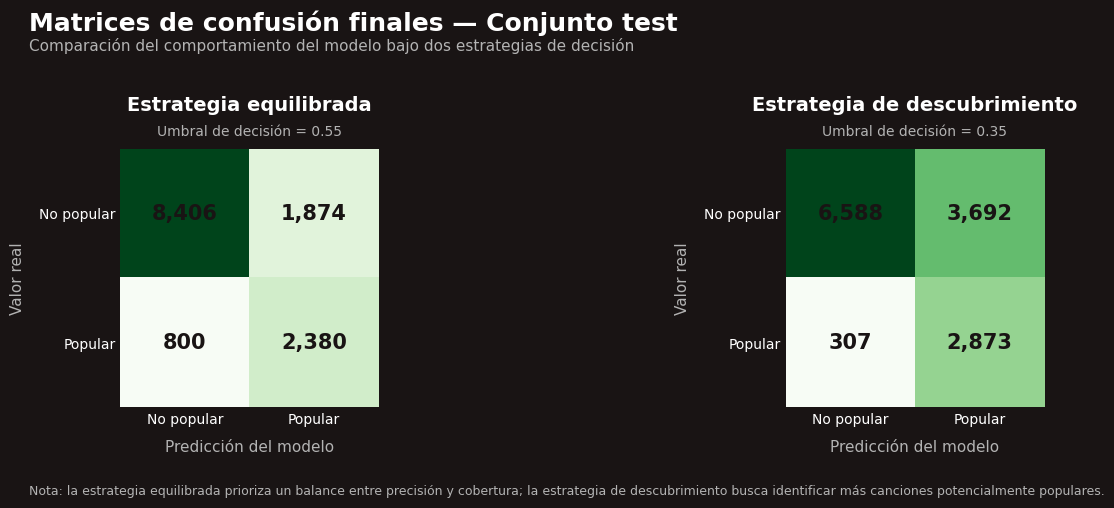

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Matrices de confusión finales sobre test
cm_balanced = confusion_matrix(y_test, y_test_pred_balanced)
cm_discovery = confusion_matrix(y_test, y_test_pred_discovery)

# Paleta Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_white = "#FFFFFF"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fondo general
fig.patch.set_facecolor(spotify_black)

matrices = [
    (
        axes[0],
        cm_balanced,
        "Estrategia equilibrada",
        "Umbral de decisión = 0.55"
    ),
    (
        axes[1],
        cm_discovery,
        "Estrategia de descubrimiento",
        "Umbral de decisión = 0.35"
    )
]

for ax, matrix, title, subtitle in matrices:
    ax.set_facecolor(spotify_dark)

    # Heatmap
    image = ax.imshow(matrix, cmap="Greens")

    # Título individual
    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        color=spotify_white,
        pad=28
    )

    # Subtítulo individual
    ax.text(
        0.5,
        1.04,
        subtitle,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        color=spotify_gray
    )

    # Etiquetas de ejes
    ax.set_xlabel(
        "Predicción del modelo",
        fontsize=11,
        color=spotify_gray,
        labelpad=10
    )

    ax.set_ylabel(
        "Valor real",
        fontsize=11,
        color=spotify_gray,
        labelpad=10
    )

    # Etiquetas de clases
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        ["No popular", "Popular"],
        fontsize=10,
        color=spotify_white
    )

    ax.set_yticks([0, 1])
    ax.set_yticklabels(
        ["No popular", "Popular"],
        fontsize=10,
        color=spotify_white
    )

    # Valores dentro de las celdas: todos negros
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j,
                i,
                f"{matrix[i, j]:,}",
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold",
                color=spotify_black
            )

    # Quitar bordes y marcas
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)

# Título principal
fig.text(
    0.125,
    0.96,
    "Matrices de confusión finales — Conjunto test",
    color=spotify_white,
    fontsize=18,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Comparación del comportamiento del modelo bajo dos estrategias de decisión",
    color=spotify_gray,
    fontsize=11
)

# Nota inferior
fig.text(
    0.125,
    0.03,
    "Nota: la estrategia equilibrada prioriza un balance entre precisión y cobertura; la estrategia de descubrimiento busca identificar más canciones potencialmente populares.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.86])

plt.savefig(
    "../reports/figures/final_confusion_matrices_test_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [8]:
# Impacto de negocio final sobre test
# Supuestos ilustrativos definidos previamente:
# TP = +10,000 USD | FP = -2,000 USD | FN = -8,000 USD | TN = 0 USD

business_values = {
    "TP": 10000,
    "FP": -2000,
    "FN": -8000,
    "TN": 0
}

def calculate_business_impact(confusion_matrix_values, strategy_name):
    tn, fp, fn, tp = confusion_matrix_values.ravel()

    impact = (
        tp * business_values["TP"]
        + fp * business_values["FP"]
        + fn * business_values["FN"]
        + tn * business_values["TN"]
    )

    return {
        "Estrategia": strategy_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Impacto_estimado_USD": impact,
        "Canciones_para_revision": tp + fp
    }

final_business_impact = pd.DataFrame([
    calculate_business_impact(
        cm_balanced,
        "Equilibrada — umbral 0.55"
    ),
    calculate_business_impact(
        cm_discovery,
        "Descubrimiento — umbral 0.35"
    )
])

final_business_impact.style.format({
    "Impacto_estimado_USD": "${:,.0f}"
})

,Estrategia,TP,FP,FN,TN,Impacto_estimado_USD,Canciones_para_revision
0,Equilibrada — umbral 0.55,2380,1874,800,8406,"$13,652,000",4254
1,Descubrimiento — umbral 0.35,2873,3692,307,6588,"$18,890,000",6565


### Decisión final sobre estrategias de uso

La evaluación final sobre test confirma que ambas estrategias son útiles, pero responden a necesidades operativas distintas.

| Estrategia | Umbral | Uso recomendado | Principal ventaja | Principal costo |
|---|---:|---|---|---|
| Equilibrada | 0.55 | Priorización regular de canciones | Mejor balance entre precision y recall | Puede dejar sin revisar algunas canciones populares |
| Descubrimiento | 0.35 | Exploración amplia o campañas de scouting | Detecta una mayor proporción de canciones populares | Aumenta la cantidad de canciones que requieren revisión humana |

Aunque la estrategia de descubrimiento presenta mayor impacto económico estimado bajo los supuestos académicos definidos, requiere revisar un volumen considerablemente mayor de canciones.

Por ello, se recomienda utilizar el umbral `0.55` como configuración operativa principal y habilitar el umbral `0.35` como modo de descubrimiento cuando exista mayor capacidad de revisión por parte del equipo A&R.

Los valores monetarios utilizados son ilustrativos y no representan retornos reales garantizados. El modelo debe utilizarse como herramienta de apoyo a la decisión y no como mecanismo automático de inversión.

## Fairness final por género en test

La evaluación final de fairness se realiza sobre el conjunto de test, sin usar estos resultados para modificar el modelo ni los umbrales.

Se comparan las estrategias:

- **Equilibrada:** umbral `0.55`.
- **Descubrimiento:** umbral `0.35`.

Para evitar métricas inestables, se consideran únicamente géneros con al menos 100 canciones y 20 canciones populares reales.

In [10]:
# Fairness final por género sobre test

def calculate_genre_fairness(
    X_data,
    y_true,
    y_pred,
    min_songs=100,
    min_positive_cases=20
):
    fairness_data = X_data[["genres"]].copy()

    fairness_data["popular_real"] = y_true.values
    fairness_data["popular_predicho"] = y_pred

    fairness_expanded = (
        fairness_data
        .assign(genre=fairness_data["genres"].str.split("|"))
        .explode("genre")
        .drop(columns="genres")
    )

    genre_summary = (
        fairness_expanded
        .groupby("genre")
        .agg(
            Canciones=("popular_real", "size"),
            Populares_reales=("popular_real", "sum")
        )
        .reset_index()
    )

    eligible_genres = genre_summary[
        (genre_summary["Canciones"] >= min_songs)
        & (genre_summary["Populares_reales"] >= min_positive_cases)
    ]["genre"]

    results = []

    for genre in eligible_genres:
        group = fairness_expanded[
            fairness_expanded["genre"] == genre
        ]

        results.append({
            "Género": genre,
            "Canciones": len(group),
            "Populares_reales": group["popular_real"].sum(),
            "Precision": precision_score(
                group["popular_real"],
                group["popular_predicho"],
                zero_division=0
            ),
            "Recall": recall_score(
                group["popular_real"],
                group["popular_predicho"],
                zero_division=0
            ),
            "F1-score": f1_score(
                group["popular_real"],
                group["popular_predicho"],
                zero_division=0
            )
        })

    return pd.DataFrame(results)


fairness_test_balanced = calculate_genre_fairness(
    X_test,
    y_test,
    y_test_pred_balanced
)

fairness_test_discovery = calculate_genre_fairness(
    X_test,
    y_test,
    y_test_pred_discovery
)

print(
    "Géneros evaluados — estrategia equilibrada:",
    len(fairness_test_balanced)
)

print(
    "Géneros evaluados — estrategia descubrimiento:",
    len(fairness_test_discovery)
)

Géneros evaluados — estrategia equilibrada: 76
Géneros evaluados — estrategia descubrimiento: 76


In [11]:
# Comparación de fairness entre estrategias sobre test

fairness_comparison_test = (
    fairness_test_balanced
    .rename(columns={
        "Precision": "Precision_equilibrada",
        "Recall": "Recall_equilibrada",
        "F1-score": "F1_equilibrada"
    })
    .merge(
        fairness_test_discovery[
            ["Género", "Precision", "Recall", "F1-score"]
        ].rename(columns={
            "Precision": "Precision_descubrimiento",
            "Recall": "Recall_descubrimiento",
            "F1-score": "F1_descubrimiento"
        }),
        on="Género",
        how="inner"
    )
)

fairness_comparison_test["Cambio_F1_descubrimiento"] = (
    fairness_comparison_test["F1_descubrimiento"]
    - fairness_comparison_test["F1_equilibrada"]
)

fairness_comparison_test = (
    fairness_comparison_test
    .sort_values("Cambio_F1_descubrimiento")
    .reset_index(drop=True)
)

fairness_comparison_test[
    [
        "Género",
        "Canciones",
        "Populares_reales",
        "F1_equilibrada",
        "F1_descubrimiento",
        "Cambio_F1_descubrimiento"
    ]
].head(10).style.format({
    "F1_equilibrada": "{:.2%}",
    "F1_descubrimiento": "{:.2%}",
    "Cambio_F1_descubrimiento": "{:+.2%}"
})

,Género,Canciones,Populares_reales,F1_equilibrada,F1_descubrimiento,Cambio_F1_descubrimiento
0,hardcore,152,43,69.47%,57.81%,-11.66%
1,show-tunes,160,29,40.00%,28.57%,-11.43%
2,folk,143,46,63.41%,53.57%,-9.84%
3,swedish,166,53,63.33%,54.08%,-9.25%
4,j-rock,150,44,68.97%,60.15%,-8.82%
5,blues,145,38,61.54%,52.86%,-8.68%
6,reggaeton,146,29,51.43%,42.99%,-8.44%
7,groove,143,54,70.77%,62.65%,-8.12%
8,dance,168,47,55.28%,47.25%,-8.03%
9,edm,167,73,69.61%,62.34%,-7.27%


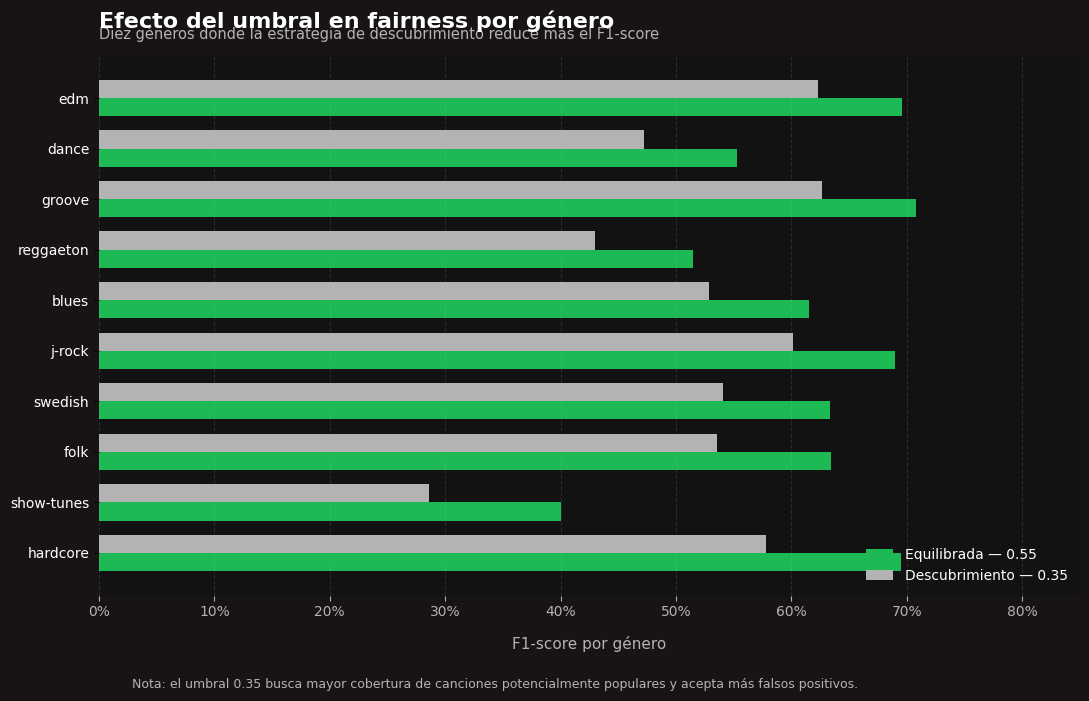

In [12]:
# Comparación de F1 por género entre estrategias
# Se visualizan los 10 géneros donde descubrimiento reduce más el F1-score.

fairness_plot_test = (
    fairness_comparison_test
    .head(10)
    .sort_values("Cambio_F1_descubrimiento", ascending=True)
)

y_positions = np.arange(len(fairness_plot_test))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

ax.barh(
    y_positions - bar_height / 2,
    fairness_plot_test["F1_equilibrada"],
    height=bar_height,
    label="Equilibrada — 0.55",
    color=spotify_green
)

ax.barh(
    y_positions + bar_height / 2,
    fairness_plot_test["F1_descubrimiento"],
    height=bar_height,
    label="Descubrimiento — 0.35",
    color=spotify_gray
)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    fairness_plot_test["Género"],
    fontsize=10,
    color=spotify_white
)

ax.set_xlabel(
    "F1-score por género",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_xlim(0, 0.85)

ax.set_title(
    "Efecto del umbral en fairness por género",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Diez géneros donde la estrategia de descubrimiento reduce más el F1-score",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.tick_params(axis="x", colors=spotify_gray)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.16,
    color=spotify_gray
)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(spotify_white)

fig.text(
    0.125,
    0.01,
    "Nota: el umbral 0.35 busca mayor cobertura de canciones potencialmente populares y acepta más falsos positivos.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Conclusión final de fairness en test

La evaluación final se realizó sobre 76 géneros con soporte suficiente en el conjunto de test.

La estrategia de descubrimiento (`umbral = 0.35`) mejora la cobertura global de canciones populares, pero puede reducir el F1-score en determinados géneros debido al incremento de falsos positivos.

Las mayores reducciones observadas se presentaron en:

- `hardcore`: −11,66 puntos porcentuales.
- `show-tunes`: −11,43 puntos porcentuales.
- `folk`: −9,84 puntos porcentuales.
- `swedish`: −9,25 puntos porcentuales.
- `j-rock`: −8,82 puntos porcentuales.

Por esta razón, la estrategia equilibrada (`umbral = 0.55`) se recomienda como configuración principal para la operación regular del equipo A&R.

La estrategia de descubrimiento debe utilizarse en escenarios donde se priorice identificar la mayor cantidad posible de canciones potencialmente populares, como campañas de scouting, convocatorias abiertas o exploración de nuevos catálogos.

Las métricas por género deben monitorearse en futuras versiones del modelo. Los resultados no deben interpretarse como evidencia de discriminación, sino como una diferencia de rendimiento entre segmentos musicales con tasas base de popularidad distintas.

## Exportación de resultados finales

Se guardan los resultados de evaluación en archivos reutilizables para documentación, dashboard y seguimiento del modelo.

In [14]:
from pathlib import Path

# Carpeta para resultados tabulares
reports_tables_path = Path("../reports/tables")
reports_tables_path.mkdir(parents=True, exist_ok=True)

# Exportar métricas finales en test
final_test_results.to_csv(
    reports_tables_path / "final_test_metrics.csv",
    index=False
)

# Exportar impacto de negocio en test
final_business_impact.to_csv(
    reports_tables_path / "final_business_impact.csv",
    index=False
)

# Exportar fairness por género para ambas estrategias
fairness_test_balanced.to_csv(
    reports_tables_path / "fairness_test_balanced.csv",
    index=False
)

fairness_test_discovery.to_csv(
    reports_tables_path / "fairness_test_discovery.csv",
    index=False
)

# Exportar comparación entre estrategias
fairness_comparison_test.to_csv(
    reports_tables_path / "fairness_comparison_test.csv",
    index=False
)

print("Archivos exportados correctamente:")
for file in sorted(reports_tables_path.glob("*.csv")):
    print("•", file.name)

Archivos exportados correctamente:
• fairness_comparison_test.csv
• fairness_test_balanced.csv
• fairness_test_discovery.csv
• final_business_impact.csv
• final_test_metrics.csv


## Persistencia del modelo final

Se guardan el modelo entrenado, el preprocesador numérico, el codificador de géneros y la configuración de los umbrales de decisión.

In [15]:
from pathlib import Path
import joblib
import json

# Carpeta de artefactos del modelo
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

# Guardar componentes necesarios para futuras predicciones
joblib.dump(
    final_hgb_model,
    models_path / "hgb_spotify_final.joblib"
)

joblib.dump(
    preprocessor_final,
    models_path / "numeric_preprocessor_final.joblib"
)

joblib.dump(
    mlb_final,
    models_path / "genre_encoder_final.joblib"
)

# Guardar configuración y trazabilidad básica
model_metadata = {
    "model_name": "HistGradientBoostingClassifier",
    "dataset": "spotify_model_dataset.csv",
    "train_validation_rows": int(X_train_val.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "numeric_features": numeric_features,
    "genre_features_count": int(len(mlb_final.classes_)),
    "total_model_features": int(X_train_val_final.shape[1]),
    "threshold_balanced": threshold_balanced,
    "threshold_discovery": threshold_discovery,
    "test_roc_auc": float(roc_auc_score(y_test, y_test_proba_final)),
    "test_pr_auc": float(average_precision_score(y_test, y_test_proba_final)),
    "random_state": 42
}

with open(models_path / "model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, indent=4, ensure_ascii=False)

print("Artefactos guardados correctamente:")
for file in sorted(models_path.iterdir()):
    print("•", file.name)

Artefactos guardados correctamente:
• .gitkeep
• genre_encoder_final.joblib
• hgb_spotify_final.joblib
• model_metadata.json
• numeric_preprocessor_final.joblib


In [17]:
%pip install mlflow

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.6 MB 7.1 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.6 MB 8.4 MB/s eta 0:00:01
   ----------------------- ---------------- 7.3/12.6 MB 9.8 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.6 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 10.6 MB/s  0:00:01
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ------------ --------------------------- 1.0/3.5 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 10.8 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 13.2 MB/s  0:00:00
   -----------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.1.0 requires cryptography<43,>=41.0.5, but you have cryptography 48.0.1 which is incompatible.
python-telegram-bot 13.15 requires cachetools==4.2.2, but you have cachetools 7.1.4 which is incompatible.


In [18]:
import mlflow

print(f"MLflow disponible. Versión: {mlflow.__version__}")

MLflow disponible. Versión: 3.14.0


In [21]:
import mlflow
import mlflow.sklearn

# Tracking local con SQLite dentro del repositorio
mlflow_db_path = Path("../mlflow.db").resolve()

mlflow.set_tracking_uri(
    f"sqlite:///{mlflow_db_path.as_posix()}"
)

# Crear o seleccionar el experimento
mlflow.set_experiment("spotify_hit_predictor")

# Filas de resultados para acceder a cada estrategia
balanced_metrics = final_test_results[
    final_test_results["Estrategia"] == "Equilibrada — umbral 0.55"
].iloc[0]

discovery_metrics = final_test_results[
    final_test_results["Estrategia"] == "Descubrimiento — umbral 0.35"
].iloc[0]

balanced_impact = final_business_impact[
    final_business_impact["Estrategia"] == "Equilibrada — umbral 0.55"
].iloc[0]

discovery_impact = final_business_impact[
    final_business_impact["Estrategia"] == "Descubrimiento — umbral 0.35"
].iloc[0]

with mlflow.start_run(run_name="hgb_final_test_evaluation") as run:

    # Etiquetas para identificar fácilmente la ejecución
    mlflow.set_tags({
        "project": "spotify_hit_predictor",
        "model_type": "HistGradientBoostingClassifier",
        "evaluation_dataset": "test",
        "status": "final_candidate",
        "owner": "Gabriela Cárdenas"
    })

    # Hiperparámetros y configuración
    mlflow.log_params({
        "learning_rate": final_hgb_model.learning_rate,
        "max_iter": final_hgb_model.max_iter,
        "max_leaf_nodes": final_hgb_model.max_leaf_nodes,
        "min_samples_leaf": final_hgb_model.min_samples_leaf,
        "l2_regularization": final_hgb_model.l2_regularization,
        "class_weight": "balanced",
        "random_state": 42,
        "numeric_features": len(numeric_features),
        "genre_features": len(mlb_final.classes_),
        "total_features": X_train_val_final.shape[1],
        "threshold_balanced": threshold_balanced,
        "threshold_discovery": threshold_discovery
    })

    # Métricas de la estrategia equilibrada
    mlflow.log_metrics({
        "balanced_accuracy": float(balanced_metrics["Accuracy"]),
        "balanced_precision": float(balanced_metrics["Precision"]),
        "balanced_recall": float(balanced_metrics["Recall"]),
        "balanced_f1": float(balanced_metrics["F1-score"]),
        "test_roc_auc": float(balanced_metrics["ROC-AUC"]),
        "test_pr_auc": float(balanced_metrics["PR-AUC"]),
        "balanced_business_impact_usd": float(
            balanced_impact["Impacto_estimado_USD"]
        ),
        "balanced_review_volume": float(
            balanced_impact["Canciones_para_revision"]
        )
    })

    # Métricas de la estrategia de descubrimiento
    mlflow.log_metrics({
        "discovery_accuracy": float(discovery_metrics["Accuracy"]),
        "discovery_precision": float(discovery_metrics["Precision"]),
        "discovery_recall": float(discovery_metrics["Recall"]),
        "discovery_f1": float(discovery_metrics["F1-score"]),
        "discovery_business_impact_usd": float(
            discovery_impact["Impacto_estimado_USD"]
        ),
        "discovery_review_volume": float(
            discovery_impact["Canciones_para_revision"]
        )
    })

    # Tablas finales y metadata como artefactos
    for file in reports_tables_path.glob("*.csv"):
        mlflow.log_artifact(str(file), artifact_path="tables")

    mlflow.log_artifact(
        str(models_path / "model_metadata.json"),
        artifact_path="metadata"
    )

    mlflow.log_artifact(
        str(models_path / "numeric_preprocessor_final.joblib"),
        artifact_path="preprocessing"
    )

    mlflow.log_artifact(
        str(models_path / "genre_encoder_final.joblib"),
        artifact_path="preprocessing"
    )

    # Registrar el clasificador final en formato MLflow
    mlflow.sklearn.log_model(
        sk_model=final_hgb_model,
        name="hgb_spotify_final"
    )

    print("Run ID:", run.info.run_id)
    print("Tracking URI:", mlflow.get_tracking_uri())
    print("Experimento registrado: spotify_hit_predictor")

2026/06/30 02:56:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/30 02:56:09 INFO mlflow.store.db.utils: Updating database tables
2026/06/30 02:56:11 INFO mlflow.tracking.fluent: Experiment with name 'spotify_hit_predictor' does not exist. Creating a new experiment.


Run ID: 284bf9b4a80247e1873d4db72a3f7888
Tracking URI: sqlite:///C:/Users/GABY/Documents/Ciencia de Datos - Puce/spotify-tracks-ml/mlflow.db
Experimento registrado: spotify_hit_predictor


In [22]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

experiment = client.get_experiment_by_name("spotify_hit_predictor")

print("Experimento:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"],
    max_results=5
)

runs[
    [
        "run_id",
        "status",
        "metrics.balanced_f1",
        "metrics.discovery_recall",
        "metrics.test_roc_auc",
        "metrics.test_pr_auc",
        "metrics.discovery_business_impact_usd"
    ]
]

Experimento: spotify_hit_predictor
Experiment ID: 1


,run_id,status,metrics.balanced_f1,metrics.discovery_recall,metrics.test_roc_auc,metrics.test_pr_auc,metrics.discovery_business_impact_usd
0,284bf9b4a80247e1873d4db72a3f7888,FINISHED,0.640301,0.903459,0.86982,0.686026,18890000.0


## Trazabilidad con MLflow

La evaluación final fue registrada en MLflow mediante un backend local SQLite (`mlflow.db`).

El experimento registrado es:

- **Experimento:** `spotify_hit_predictor`
- **Modelo:** `HistGradientBoostingClassifier`
- **Estado de ejecución:** `FINISHED`
- **Dataset de evaluación:** test
- **Run ID:** `284bf9b4a80247e1873d4db72a3f7888`

MLflow almacena:

- Hiperparámetros del modelo final.
- Métricas de test para ambas estrategias.
- Impacto de negocio estimado.
- Archivos CSV de métricas, impacto y fairness.
- Metadata del modelo.
- Preprocesador numérico y codificador de géneros.
- Modelo final serializado en formato MLflow.

Esto permite reproducir la evaluación final y conservar evidencia de las decisiones técnicas del proyecto.

## Fairness agrupado: mainstream vs. latino / emergente

Además del análisis individual por género, se realizará una comparación entre dos grupos musicales agregados.

Los grupos se construirán únicamente con etiquetas que existan realmente en el dataset. Para evitar duplicar canciones, se excluirán del análisis las canciones que pertenezcan simultáneamente a ambos grupos.

Se compararán:

- Número de observaciones.
- Tasa de predicción positiva.
- Precision.
- Recall de canciones populares.
- F1-score.

La métrica principal de fairness será el recall, ya que una brecha elevada puede indicar que el modelo deja fuera canciones populares de determinados segmentos musicales.

In [23]:
# Verificación de géneros disponibles antes de definir grupos

available_genres = set(mlb_final.classes_)

mainstream_candidates = {
    "pop",
    "edm",
    "hip-hop",
    "rock"
}

latino_emerging_candidates = {
    "latino",
    "reggaeton",
    "indie",
    "salsa",
    "afrobeat",
    "regional"
}

mainstream_genres = mainstream_candidates.intersection(available_genres)
latino_emerging_genres = latino_emerging_candidates.intersection(available_genres)

print("Géneros mainstream encontrados:", sorted(mainstream_genres))
print("Géneros latino / emergente encontrados:", sorted(latino_emerging_genres))

print("\nGéneros mainstream no disponibles:")
print(sorted(mainstream_candidates - available_genres))

print("\nGéneros latino / emergente no disponibles:")
print(sorted(latino_emerging_candidates - available_genres))

Géneros mainstream encontrados: ['edm', 'hip-hop', 'pop', 'rock']
Géneros latino / emergente encontrados: ['afrobeat', 'indie', 'latino', 'reggaeton', 'salsa']

Géneros mainstream no disponibles:
[]

Géneros latino / emergente no disponibles:
['regional']


In [24]:
# Fairness agrupado en test:
# Mainstream vs. Latino / emergente
# Se excluyen canciones que pertenecen a ambos grupos.

def assign_music_group(genres_text):
    song_genres = {
        genre.strip()
        for genre in str(genres_text).split("|")
        if genre.strip()
    }

    belongs_mainstream = bool(song_genres.intersection(mainstream_genres))
    belongs_latino_emerging = bool(
        song_genres.intersection(latino_emerging_genres)
    )

    if belongs_mainstream and not belongs_latino_emerging:
        return "Mainstream"

    if belongs_latino_emerging and not belongs_mainstream:
        return "Latino / emergente"

    if belongs_mainstream and belongs_latino_emerging:
        return "Ambos grupos"

    return "Otros géneros"


fairness_group_test = X_test[["genres"]].copy()

fairness_group_test["Grupo_musical"] = (
    fairness_group_test["genres"]
    .apply(assign_music_group)
)

fairness_group_test["popular_real"] = y_test.values
fairness_group_test["pred_balanced"] = y_test_pred_balanced
fairness_group_test["pred_discovery"] = y_test_pred_discovery

print(
    fairness_group_test["Grupo_musical"]
    .value_counts()
)

Grupo_musical
Otros géneros         12320
Latino / emergente      563
Mainstream              521
Ambos grupos             56
Name: count, dtype: int64


In [25]:
# Métricas de fairness por grupos musicales agregados en test

def calculate_group_metrics(data, prediction_column, strategy_name):
    groups_to_compare = ["Mainstream", "Latino / emergente"]

    results = []

    for group_name in groups_to_compare:
        group = data[data["Grupo_musical"] == group_name].copy()

        results.append({
            "Estrategia": strategy_name,
            "Grupo": group_name,
            "Canciones": len(group),
            "Populares_reales": int(group["popular_real"].sum()),
            "Tasa_real_popular": group["popular_real"].mean(),
            "Tasa_prediccion_positiva": group[prediction_column].mean(),
            "Precision": precision_score(
                group["popular_real"],
                group[prediction_column],
                zero_division=0
            ),
            "Recall": recall_score(
                group["popular_real"],
                group[prediction_column],
                zero_division=0
            ),
            "F1-score": f1_score(
                group["popular_real"],
                group[prediction_column],
                zero_division=0
            )
        })

    return pd.DataFrame(results)


fairness_group_balanced = calculate_group_metrics(
    fairness_group_test,
    "pred_balanced",
    "Equilibrada — umbral 0.55"
)

fairness_group_discovery = calculate_group_metrics(
    fairness_group_test,
    "pred_discovery",
    "Descubrimiento — umbral 0.35"
)

fairness_group_results = pd.concat(
    [fairness_group_balanced, fairness_group_discovery],
    ignore_index=True
)

fairness_group_results.style.format({
    "Tasa_real_popular": "{:.2%}",
    "Tasa_prediccion_positiva": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

,Estrategia,Grupo,Canciones,Populares_reales,Tasa_real_popular,Tasa_prediccion_positiva,Precision,Recall,F1-score
0,Equilibrada — umbral 0.55,Mainstream,521,246,47.22%,66.41%,66.18%,93.09%,77.36%
1,Equilibrada — umbral 0.55,Latino / emergente,563,91,16.16%,23.09%,47.69%,68.13%,56.11%
2,Descubrimiento — umbral 0.35,Mainstream,521,246,47.22%,82.34%,56.64%,98.78%,72.00%
3,Descubrimiento — umbral 0.35,Latino / emergente,563,91,16.16%,34.81%,37.24%,80.22%,50.87%


In [26]:
# Brechas de fairness entre Mainstream y Latino / emergente

fairness_group_pivot = (
    fairness_group_results
    .pivot(
        index="Estrategia",
        columns="Grupo",
        values=[
            "Precision",
            "Recall",
            "F1-score",
            "Tasa_prediccion_positiva"
        ]
    )
)

fairness_group_gaps = pd.DataFrame({
    "Estrategia": fairness_group_pivot.index,
    "Brecha_precision": (
        fairness_group_pivot[("Precision", "Mainstream")]
        - fairness_group_pivot[("Precision", "Latino / emergente")]
    ),
    "Brecha_recall": (
        fairness_group_pivot[("Recall", "Mainstream")]
        - fairness_group_pivot[("Recall", "Latino / emergente")]
    ),
    "Brecha_f1": (
        fairness_group_pivot[("F1-score", "Mainstream")]
        - fairness_group_pivot[("F1-score", "Latino / emergente")]
    ),
    "Brecha_tasa_prediccion_positiva": (
        fairness_group_pivot[("Tasa_prediccion_positiva", "Mainstream")]
        - fairness_group_pivot[
            ("Tasa_prediccion_positiva", "Latino / emergente")
        ]
    )
}).reset_index(drop=True)

fairness_group_gaps.style.format({
    "Brecha_precision": "{:+.2%}",
    "Brecha_recall": "{:+.2%}",
    "Brecha_f1": "{:+.2%}",
    "Brecha_tasa_prediccion_positiva": "{:+.2%}"
})

,Estrategia,Brecha_precision,Brecha_recall,Brecha_f1,Brecha_tasa_prediccion_positiva
0,Descubrimiento — umbral 0.35,+19.40%,+18.56%,+21.13%,+47.53%
1,Equilibrada — umbral 0.55,+18.49%,+24.96%,+21.26%,+43.32%


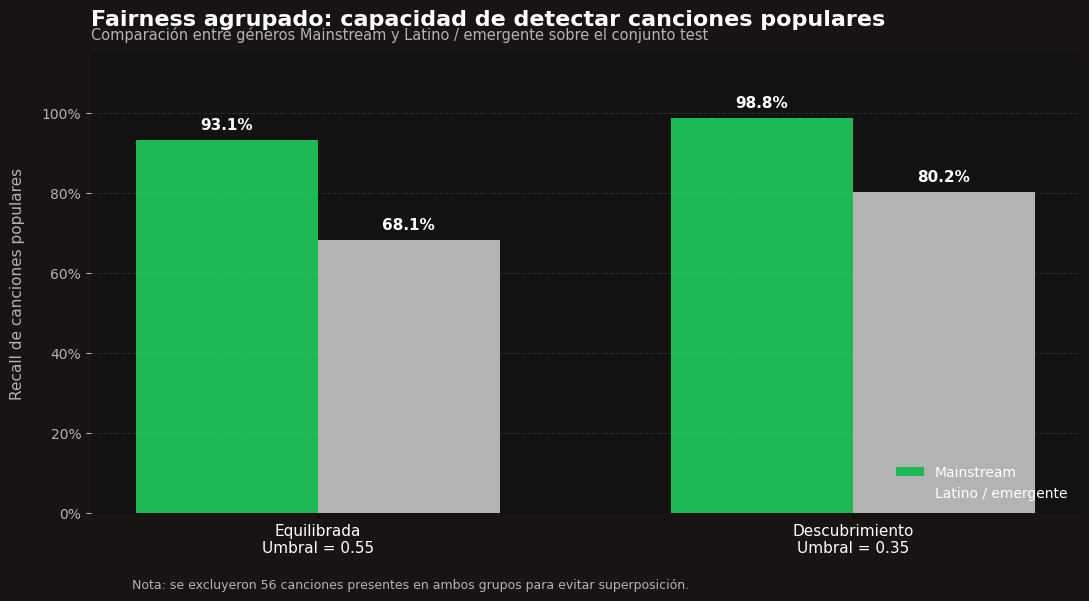

In [27]:
# Fairness agrupado: recall de canciones populares por estrategia

fairness_recall_plot = fairness_group_results.copy()

strategies_order = [
    "Equilibrada — umbral 0.55",
    "Descubrimiento — umbral 0.35"
]

groups_order = [
    "Mainstream",
    "Latino / emergente"
]

fairness_recall_plot["Estrategia"] = pd.Categorical(
    fairness_recall_plot["Estrategia"],
    categories=strategies_order,
    ordered=True
)

fairness_recall_plot["Grupo"] = pd.Categorical(
    fairness_recall_plot["Grupo"],
    categories=groups_order,
    ordered=True
)

fairness_recall_plot = fairness_recall_plot.sort_values(
    ["Estrategia", "Grupo"]
)

x = np.arange(len(strategies_order))
bar_width = 0.34

mainstream_recall = (
    fairness_recall_plot[
        fairness_recall_plot["Grupo"] == "Mainstream"
    ]["Recall"]
    .values
)

latino_recall = (
    fairness_recall_plot[
        fairness_recall_plot["Grupo"] == "Latino / emergente"
    ]["Recall"]
    .values
)

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

bars_mainstream = ax.bar(
    x - bar_width / 2,
    mainstream_recall,
    width=bar_width,
    label="Mainstream",
    color=spotify_green
)

bars_latino = ax.bar(
    x + bar_width / 2,
    latino_recall,
    width=bar_width,
    label="Latino / emergente",
    color=spotify_gray
)

for bars in [bars_mainstream, bars_latino]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=spotify_white
        )

ax.set_xticks(x)

ax.set_xticklabels(
    ["Equilibrada\nUmbral = 0.55", "Descubrimiento\nUmbral = 0.35"],
    fontsize=11,
    color=spotify_white
)

ax.set_ylim(0, 1.15)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.tick_params(axis="y", colors=spotify_gray)

ax.set_ylabel(
    "Recall de canciones populares",
    fontsize=11,
    color=spotify_gray,
    labelpad=12
)

ax.set_title(
    "Fairness agrupado: capacidad de detectar canciones populares",
    fontsize=16,
    fontweight="bold",
    color=spotify_white,
    loc="left",
    pad=20
)

ax.text(
    0,
    1.03,
    "Comparación entre géneros Mainstream y Latino / emergente sobre el conjunto test",
    transform=ax.transAxes,
    fontsize=10.5,
    color=spotify_gray
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.16,
    color=spotify_gray
)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(spotify_white)

fig.text(
    0.125,
    0.01,
    "Nota: se excluyeron 56 canciones presentes en ambos grupos para evitar superposición.",
    fontsize=9,
    color=spotify_gray
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### Conclusión de fairness agrupado

La evaluación agrupada compara canciones de los grupos **Mainstream** y **Latino / emergente**, definidos únicamente con géneros disponibles en el dataset.

| Estrategia | Recall Mainstream | Recall Latino / emergente | Brecha de recall |
|---|---:|---:|---:|
| Equilibrada — 0.55 | 93.09% | 68.13% | 24.96 puntos porcentuales |
| Descubrimiento — 0.35 | 98.78% | 80.22% | 18.56 puntos porcentuales |

En ambas estrategias se observa una brecha superior a 10 puntos porcentuales. Esto indica que el modelo identifica canciones populares del grupo Mainstream con mayor frecuencia que canciones populares del grupo Latino / emergente.

La estrategia de descubrimiento reduce parcialmente la brecha de recall, debido a que prioriza detectar más canciones potencialmente populares. Sin embargo, también incrementa el número de falsos positivos y el volumen de revisión humana requerido.

Este resultado se interpreta como un **riesgo de cobertura del modelo**, no como evidencia automática de discriminación. Los grupos representan segmentos musicales y tienen tasas base de popularidad distintas.

Como medida de mitigación, se recomienda:

1. Mantener revisión humana obligatoria antes de cualquier inversión.
2. Monitorear precision, recall y F1-score por grupo en cada nueva versión.
3. Revisar manualmente canciones Latino / emergente con probabilidad cercana al umbral.
4. Considerar recolectar mayor representación histórica de géneros con menor desempeño.

In [29]:
# Exportación de fairness agrupado por segmentos musicales

fairness_group_results.to_csv(
    reports_tables_path / "fairness_group_results_test.csv",
    index=False
)

fairness_group_gaps.to_csv(
    reports_tables_path / "fairness_group_gaps_test.csv",
    index=False
)

print("Archivos exportados correctamente:")
print("• fairness_group_results_test.csv")
print("• fairness_group_gaps_test.csv")

Archivos exportados correctamente:
• fairness_group_results_test.csv
• fairness_group_gaps_test.csv
